# 04 — Themes-only clustering (beyt_hint | ghazal_axis)

**Purpose**
Discover semantic “themes” that exist beyond the affect labels by clustering embeddings of:

- `theme_text = beyt_hint | ghazal_axis`

**Key constraints**
- We do **not** include `affect` tokens inside the embedded text.
- `affect` is used only as an *overlay* (post-hoc analysis) to interpret clusters.

**Outputs**
- Embeddings are saved once to `../data/embeddings/`
- Reports (tables/figures) are saved to `../data/reports/04_themes_only_clustering/`

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import List, Dict, Tuple
import numpy as np
import pandas as pd

# ---- Project paths (run notebook from notebooks/) ----
DATA_DIR   = Path("../data")
ANNOT_PATH = DATA_DIR / "annotations" / "beyt_annotations_v1_3.jsonl"

EMB_DIR    = DATA_DIR / "embeddings"
REPORT_DIR = DATA_DIR / "reports" / "04_themes_only_clustering"

EMB_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

assert ANNOT_PATH.exists(), f"Missing annotations file: {ANNOT_PATH.resolve()}"

print("ANNOT_PATH:", ANNOT_PATH)
print("EMB_DIR:", EMB_DIR)
print("REPORT_DIR:", REPORT_DIR)

ANNOT_PATH: ../data/annotations/beyt_annotations_v1_3.jsonl
EMB_DIR: ../data/embeddings
REPORT_DIR: ../data/reports/04_themes_only_clustering


## Load annotations (schema locked)

We expect each row to contain:

- `poem_id` (int)
- `beyt_id` (int)
- `beyt_hint` (short semantic hint)
- `ghazal_axis` (ghazal-level context label)
- `affect` (list of 0–2 affect labels)

Then we build:

- `theme_text = beyt_hint | ghazal_axis`

and compute quick diagnostics:
- row count (should be 4192)
- affect length distribution
- ghazal_axis non-empty (should be 100%)

In [2]:
def _normalize_affect(x) -> List[str]:
    # Your schema says affect is always a list (possibly empty).
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    if isinstance(x, list):
        # strip whitespace, drop empties
        out = []
        for t in x:
            s = str(t).strip()
            if s:
                out.append(s)
        return out
    raise TypeError(f"Expected affect as list, got {type(x)}")

def load_annotations(path: Path) -> pd.DataFrame:
    df = pd.read_json(path, lines=True)
    df.columns = [c.strip() for c in df.columns]

    required = ["poem_id", "beyt_id", "beyt_hint", "ghazal_axis", "affect"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}. Columns: {list(df.columns)}")

    df["poem_id"] = df["poem_id"].astype(int)
    df["beyt_id"] = df["beyt_id"].astype(int)
    df["beyt_hint"] = df["beyt_hint"].astype(str).str.strip()
    df["ghazal_axis"] = df["ghazal_axis"].astype(str).str.strip()
    df["affect"] = df["affect"].apply(_normalize_affect)

    # main text for themes-only clustering
    df["theme_text"] = df["beyt_hint"] + " | " + df["ghazal_axis"]

    # defensive: stable key sort and dedupe
    df = (
        df.drop_duplicates(["poem_id", "beyt_id"], keep="first")
          .sort_values(["poem_id", "beyt_id"])
          .reset_index(drop=True)
    )
    return df

df = load_annotations(ANNOT_PATH)

print("Rows:", len(df))
print("Non-empty ghazal_axis:", int((df["ghazal_axis"].str.len() > 0).sum()))
aff_len = df["affect"].apply(len).value_counts().sort_index()
print("\nAffect length distribution:")
print(aff_len)

print("\nTheme_text examples:")
print(df[["poem_id", "beyt_id", "theme_text"]].head(3).to_string(index=False))

Rows: 4192
Non-empty ghazal_axis: 4192

Affect length distribution:
affect
0     296
1    2056
2    1840
Name: count, dtype: int64

Theme_text examples:
 poem_id  beyt_id                                                    theme_text
       1        1 درخواست شراب از ساقی، بیان دشواری عشق | پیچیدگی راه و منزلگاه
       1        2    انتظار پیام معشوق و تاثیر زلف معطر | پیچیدگی راه و منزلگاه
       1        3         ناپایداری اقامت در منزل معشوق | پیچیدگی راه و منزلگاه


## Embedding artifacts (cached)

We embed `theme_text` with `BAAI/bge-m3` and cache the result to avoid recomputation.

We store embeddings as a **wide parquet**:

- `poem_id`, `beyt_id`, then `e0000..e1023`

This format is:
- easy to load fast
- easy to use with PCA/HDBSCAN
- stable for future notebooks

In [3]:
MODEL_NAME = "BAAI/bge-m3"
MODEL_TAG  = "bge-m3"
VERSION_TAG = "v1_3"

EMB_WIDE_PATH = EMB_DIR / f"theme_text_embeddings_{MODEL_TAG}_{VERSION_TAG}.parquet"

print("Will write embeddings to:", EMB_WIDE_PATH)

Will write embeddings to: ../data/embeddings/theme_text_embeddings_bge-m3_v1_3.parquet


## Compute embeddings (cached)

We embed `theme_text = beyt_hint | ghazal_axis` using:

- `SentenceTransformer("BAAI/bge-m3")`
- `normalize_embeddings=True`

We cache a **wide parquet** in `../data/embeddings/` so this notebook (and future notebooks) never recompute embeddings unless you delete the file.

In [4]:
import numpy as np
import pandas as pd

def embed_texts_bge_m3(texts, model_name: str, batch_size: int = 64) -> np.ndarray:
    try:
        from sentence_transformers import SentenceTransformer
    except Exception as e:
        raise RuntimeError("Install sentence-transformers: pip install sentence-transformers") from e

    model = SentenceTransformer(model_name)
    X = model.encode(
        list(texts),
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    X = np.asarray(X, dtype=np.float32)
    if X.ndim != 2:
        raise RuntimeError(f"Expected 2D embeddings, got shape={X.shape}")
    return X

def save_wide_embeddings_parquet(keys: pd.DataFrame, X: np.ndarray, out_path, prefix: str = "e"):
    out_path = Path(out_path)
    if X.shape[0] != len(keys):
        raise ValueError(f"Row mismatch: keys={len(keys)} vs X={X.shape[0]}")
    d = X.shape[1]
    cols = {f"{prefix}{i:04d}": X[:, i] for i in range(d)}
    wide = pd.concat([keys.reset_index(drop=True), pd.DataFrame(cols)], axis=1)
    wide.to_parquet(out_path, index=False)
    print(f"Saved wide parquet: {out_path} | shape={X.shape} | cols={len(wide.columns)}")

def load_wide_embeddings_parquet(path, prefix: str = "e"):
    path = Path(path)
    dfw = pd.read_parquet(path)
    for c in ["poem_id", "beyt_id"]:
        if c not in dfw.columns:
            raise ValueError(f"Missing key column {c} in {path}")
    emb_cols = [c for c in dfw.columns if c.startswith(prefix)]
    if not emb_cols:
        raise ValueError(f"No embedding columns with prefix '{prefix}' found in {path}")
    emb_cols = sorted(emb_cols)
    X = dfw[emb_cols].to_numpy(dtype=np.float32, copy=True)
    keys = dfw[["poem_id", "beyt_id"]].copy()
    return keys, X, emb_cols

# --- cache logic ---
if EMB_WIDE_PATH.exists():
    keys_emb, X, emb_cols = load_wide_embeddings_parquet(EMB_WIDE_PATH, prefix="e")
    print("Loaded cached embeddings:", EMB_WIDE_PATH)
else:
    print("Embedding theme_text with:", MODEL_NAME)
    X = embed_texts_bge_m3(df["theme_text"], model_name=MODEL_NAME, batch_size=64)
    keys = df[["poem_id", "beyt_id"]].copy()
    save_wide_embeddings_parquet(keys, X, EMB_WIDE_PATH, prefix="e")
    keys_emb, _, emb_cols = load_wide_embeddings_parquet(EMB_WIDE_PATH, prefix="e")  # sanity reload

print("X shape:", X.shape)
print("First/last embedding col:", emb_cols[0], emb_cols[-1])

Loaded cached embeddings: ../data/embeddings/theme_text_embeddings_bge-m3_v1_3.parquet
X shape: (4192, 1024)
First/last embedding col: e0000 e1023


## PCA: diagnostic curve + PCA256 for clustering

We use PCA in two ways:

1) **Diagnostic:** full cumulative explained-variance curve to quantify intrinsic dimensionality.
2) **Working representation:** PCA(256) as a denoised, faster input for clustering (HDBSCAN/KMeans).

Important:
- PCA(256) is **not** intended to replace embeddings for retrieval.
- It is a pragmatic step for clustering stability + speed.

PCA input X: (4192, 1024)
k80=128  k90=209  k95=291
Saved: ../data/reports/04_themes_only_clustering/pca_theme_text_explained_variance_curve.csv


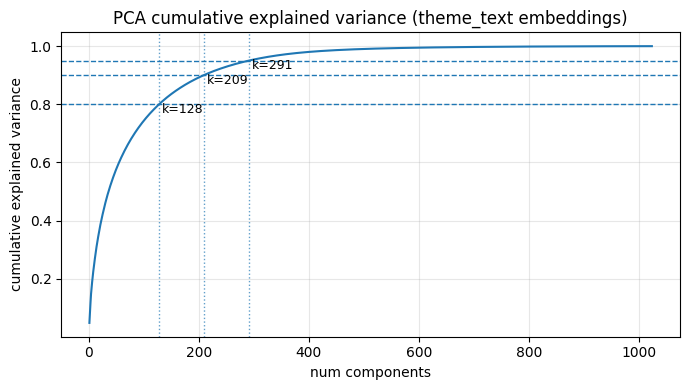

Saved: ../assets/plots/pca_theme_text_explained_variance_curve.png


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

ASSETS_PLOTS = Path("../assets/plots")
ASSETS_PLOTS.mkdir(parents=True, exist_ok=True)

PCA_CURVE_PNG = ASSETS_PLOTS / "pca_theme_text_explained_variance_curve.png"
PCA_CURVE_CSV = REPORT_DIR / "pca_theme_text_explained_variance_curve.csv"

n, d = X.shape
print("PCA input X:", X.shape)

pca_full = PCA(n_components=d, svd_solver="full", random_state=0)
pca_full.fit(X)

evr = pca_full.explained_variance_ratio_
cev = np.cumsum(evr)

def k_for(target: float) -> int:
    return int(np.searchsorted(cev, target) + 1)

k80, k90, k95 = k_for(0.80), k_for(0.90), k_for(0.95)
print(f"k80={k80}  k90={k90}  k95={k95}")

curve = pd.DataFrame({
    "k": np.arange(1, d + 1),
    "explained_variance_ratio": evr,
    "cumulative_explained_variance": cev,
})
curve.to_csv(PCA_CURVE_CSV, index=False, encoding="utf-8")
print("Saved:", PCA_CURVE_CSV)

plt.figure(figsize=(7,4))
plt.plot(curve["k"], curve["cumulative_explained_variance"])
plt.axhline(0.80, linestyle="--", linewidth=1)
plt.axhline(0.90, linestyle="--", linewidth=1)
plt.axhline(0.95, linestyle="--", linewidth=1)
plt.grid(True, alpha=0.3)
plt.title("PCA cumulative explained variance (theme_text embeddings)")
plt.xlabel("num components")
plt.ylabel("cumulative explained variance")

for k, y in [(k80, 0.80), (k90, 0.90), (k95, 0.95)]:
    plt.axvline(k, linestyle=":", linewidth=1, alpha=0.7)
    plt.text(k+5, y-0.03, f"k={k}", fontsize=9)

plt.tight_layout()
plt.savefig(PCA_CURVE_PNG, dpi=200)
plt.show()

print("Saved:", PCA_CURVE_PNG)

## PCA256 artifact (wide parquet)

We compute PCA with 256 components and save it as another wide parquet:

- keys: `poem_id`, `beyt_id`
- columns: `pc000..pc255`

This becomes the default input for clustering in Notebook 04.

In [6]:
from sklearn.decomposition import PCA

PCA256_PATH = EMB_DIR / f"theme_text_pca256_{MODEL_TAG}_{VERSION_TAG}.parquet"

def save_wide_matrix_parquet(keys: pd.DataFrame, M: np.ndarray, out_path, prefix: str):
    out_path = Path(out_path)
    if M.shape[0] != len(keys):
        raise ValueError(f"Row mismatch: keys={len(keys)} vs M={M.shape[0]}")
    d = M.shape[1]
    cols = {f"{prefix}{i:03d}": M[:, i] for i in range(d)}
    wide = pd.concat([keys.reset_index(drop=True), pd.DataFrame(cols)], axis=1)
    wide.to_parquet(out_path, index=False)
    print(f"Saved: {out_path} | shape={M.shape}")

def load_wide_matrix_parquet(path, prefix: str):
    path = Path(path)
    dfw = pd.read_parquet(path)
    for c in ["poem_id", "beyt_id"]:
        if c not in dfw.columns:
            raise ValueError(f"Missing key column {c} in {path}")
    cols = sorted([c for c in dfw.columns if c.startswith(prefix)])
    if not cols:
        raise ValueError(f"No columns starting with '{prefix}' in {path}")
    M = dfw[cols].to_numpy(dtype=np.float32, copy=True)
    keys = dfw[["poem_id", "beyt_id"]].copy()
    return keys, M, cols

if PCA256_PATH.exists():
    keys_pca, X_pca256, pc_cols = load_wide_matrix_parquet(PCA256_PATH, prefix="pc")
    print("Loaded cached PCA256:", PCA256_PATH)
else:
    pca256 = PCA(n_components=256, svd_solver="full", random_state=0)
    X_pca256 = pca256.fit_transform(X).astype(np.float32)
    save_wide_matrix_parquet(keys_emb, X_pca256, PCA256_PATH, prefix="pc")
    keys_pca, _, pc_cols = load_wide_matrix_parquet(PCA256_PATH, prefix="pc")

print("X_pca256 shape:", X_pca256.shape)
print("PCA256 file:", PCA256_PATH)
print("First/last PC col:", pc_cols[0], pc_cols[-1])

Loaded cached PCA256: ../data/embeddings/theme_text_pca256_bge-m3_v1_3.parquet
X_pca256 shape: (4192, 256)
PCA256 file: ../data/embeddings/theme_text_pca256_bge-m3_v1_3.parquet
First/last PC col: pc000 pc255


## Clustering strategy

We want to discover **themes beyond affect**.

- Primary: **HDBSCAN** on PCA(256)
  - Handles variable-density clusters and noise.
  - Returns `-1` for outliers (useful: not everything should be forced into a theme).

- Baseline: **KMeans**
  - Always partitions everything into k clusters.
  - Useful as a comparison, but less realistic for semantic manifolds.

Outputs:
- cluster assignments per beyt (CSV/parquet)
- cluster size table
- top TF-IDF terms per cluster (interpretability)
- affect overlay per cluster (post-hoc)
- representative examples per cluster (for manual inspection)

In [7]:
# Ensure df is aligned with X_pca256 row order
# We expect df sorted by poem_id,beyt_id (done in load cell)
df_keys = df[["poem_id","beyt_id"]].copy()

# keys_pca came from PCA256 parquet; ensure same order
tmp = df_keys.merge(keys_pca, on=["poem_id","beyt_id"], how="inner")
assert len(tmp) == len(df), "Key mismatch between df and PCA256 keys. Check duplicates/sorting."

# If ordering differs, reorder df to match keys_pca
order = (
    keys_pca.reset_index(drop=True)
    .merge(df.assign(_row=np.arange(len(df))), on=["poem_id","beyt_id"], how="left")
)

assert order["_row"].notna().all(), "Some PCA keys not found in df (unexpected)."
df = df.iloc[order["_row"].astype(int).to_numpy()].reset_index(drop=True)

# Final sanity: keys match row-by-row
assert (df[["poem_id","beyt_id"]].to_numpy() == keys_pca[["poem_id","beyt_id"]].to_numpy()).all()

print("Aligned df with X_pca256. Rows:", len(df), "X_pca256:", X_pca256.shape)

Aligned df with X_pca256. Rows: 4192 X_pca256: (4192, 256)


## HDBSCAN clustering (PCA256)

We run a small parameter grid:

- `min_cluster_size`: controls minimum theme size
- `min_samples`: controls how conservative “core points” are
- We track:
  - number of clusters
  - noise fraction (`cluster=-1`)
  - cluster size distribution

We expect:
- many points become noise (poetry is diverse)
- a moderate number of medium clusters

In [8]:
import pandas as pd
import numpy as np

def run_hdbscan_grid(X, grid):
    try:
        import hdbscan
    except Exception as e:
        raise RuntimeError("Install hdbscan: pip install hdbscan") from e

    rows = []
    labels_by_cfg = {}

    for (mcs, ms) in grid:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms,
            metric="euclidean",  # PCA space -> euclidean is standard
            cluster_selection_method="eom"
        )
        labels = clusterer.fit_predict(X)
        labels_by_cfg[(mcs, ms)] = labels

        n = len(labels)
        noise_n = int((labels == -1).sum())
        n_clusters = int(len(set(labels)) - (1 if -1 in labels else 0))

        rows.append({
            "min_cluster_size": mcs,
            "min_samples": ms,
            "n": n,
            "n_clusters": n_clusters,
            "noise_n": noise_n,
            "noise_pct": noise_n / n
        })

    return pd.DataFrame(rows).sort_values(["noise_pct","n_clusters"]), labels_by_cfg

grid = [
    (10,  1),
    (15,  1),
    (20,  1),
    (10,  5),
    (15,  5),
    (20,  5),
]

hdb_summary, hdb_labels_map = run_hdbscan_grid(X_pca256, grid)
hdb_summary

,min_cluster_size,min_samples,n,n_clusters,noise_n,noise_pct
0,10,1,4192,5,1063,0.253578
3,10,5,4192,3,2413,0.575620
1,15,1,4192,7,2499,0.596135
2,20,1,4192,3,2565,0.611880
4,15,5,4192,3,3835,0.914838
5,20,5,4192,2,3851,0.918655


In [9]:
# Choose one config (start with something reasonable)
BEST_MCS = 15
BEST_MS  = 1

labels_hdb = hdb_labels_map[(BEST_MCS, BEST_MS)]
df["cluster_hdb"] = labels_hdb

out_assign = REPORT_DIR / f"hdbscan_assignments_mcs{BEST_MCS}_ms{BEST_MS}.csv"
df[["poem_id","beyt_id","cluster_hdb"]].to_csv(out_assign, index=False, encoding="utf-8")
print("Saved:", out_assign)

# quick size table
sizes = pd.Series(labels_hdb).value_counts().sort_index()
sizes.head(), sizes.shape

Saved: ../data/reports/04_themes_only_clustering/hdbscan_assignments_mcs15_ms1.csv


(-1    2499
  0      18
  1      15
  2      15
  3      18
 Name: count, dtype: int64,
 (8,))

## Cluster interpretability: TF-IDF top terms per cluster

Embeddings give geometry, but clusters need “names”.
We compute TF-IDF over `theme_text` and extract the top terms per cluster.

Notes:
- This is for human interpretability, not model training.
- Persian tokenization is approximate; we use it as a heuristic.

In [10]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer

def simple_fa_tokenizer(s: str):
    # keep Persian letters + Arabic-Indic digits; split on whitespace/punct
    s = str(s)
    s = re.sub(r"[^\u0600-\u06FF0-9\s]+", " ", s)
    toks = [t for t in s.split() if len(t) >= 2]
    return toks

# Only non-noise clusters for interpretability
mask_in = df["cluster_hdb"].to_numpy() != -1
df_in = df.loc[mask_in, ["cluster_hdb","theme_text"]].copy()

vec = TfidfVectorizer(
    tokenizer=simple_fa_tokenizer,
    ngram_range=(1,2),
    min_df=5
)
X_tfidf = vec.fit_transform(df_in["theme_text"])
terms = np.array(vec.get_feature_names_out())

# Compute top terms per cluster by mean TF-IDF
topn = 12
rows = []
for c in sorted(df_in["cluster_hdb"].unique()):
    idx = np.where(df_in["cluster_hdb"].to_numpy() == c)[0]
    if len(idx) < 5:
        continue
    mean_w = X_tfidf[idx].mean(axis=0)
    mean_w = np.asarray(mean_w).ravel()
    top_idx = np.argsort(-mean_w)[:topn]
    rows.append({
        "cluster": int(c),
        "n": int(len(idx)),
        "top_terms": " | ".join(terms[top_idx])
    })

cluster_terms = pd.DataFrame(rows).sort_values("n", ascending=False).reset_index(drop=True)
cluster_terms.head(10)

/Users/unick/Desktop/YaarAI/.venv/lib/python3.14/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,cluster,n,top_terms
0,5,1578,معشوق | جستجوی | در | حقیقت | از | جستجوی حقیق...
1,4,26,پایان | تقدیر | آغاز | پایان رنج | وابستگی | ر...
2,6,23,جدایی | جدایی ناتوانی | تجربه جدایی | در وصال ...
3,0,18,برتر | مرجع | به مرجع | مرجع برتر | مطلق به | ...
4,3,18,ارزش | دنیوی | ارزش های | مقایسه | های | برابر...
5,1,15,یادآوری | مشترک | خاطرات مشترک | خاطرات | بازن...
6,2,15,اعتنایی به | بی | اعتدال در | اعتدال | بی اعتن...


In [11]:
# Compute affect prevalence per cluster (post-hoc overlay)
# For multi-label affects, we count membership (a beyt contributes to each of its affects)

def explode_affects(df_sub):
    rows = []
    for _, r in df_sub.iterrows():
        xs = r["affect"]
        if not xs:
            rows.append((r["cluster_hdb"], "None"))
        else:
            for a in xs:
                rows.append((r["cluster_hdb"], a))
    return pd.DataFrame(rows, columns=["cluster","affect"])

df_overlay = df[["cluster_hdb","affect"]].copy()
df_overlay = df_overlay[df_overlay["cluster_hdb"] != -1].copy()

ex = explode_affects(df_overlay)
aff_counts = ex.groupby(["cluster","affect"]).size().rename("count").reset_index()
cluster_sizes = df_overlay["cluster_hdb"].value_counts().rename_axis("cluster").rename("cluster_n").reset_index()

aff = aff_counts.merge(cluster_sizes, on="cluster", how="left")
aff["pct_of_cluster"] = aff["count"] / aff["cluster_n"]

# Top 3 affects per cluster
top_aff = (
    aff.sort_values(["cluster","pct_of_cluster"], ascending=[True, False])
       .groupby("cluster")
       .head(3)
       .reset_index(drop=True)
)

top_aff.head(20)

,cluster,affect,count,cluster_n,pct_of_cluster
0,0,None,7,18,0.388889
1,0,آرامش,5,18,0.277778
2,0,امید,5,18,0.277778
3,1,حسرت,12,15,0.800000
4,1,آرامش,5,15,0.333333
5,1,اندوه,1,15,0.066667
6,2,آرامش,7,15,0.466667
7,2,None,5,15,0.333333
8,2,بی‌قراری,1,15,0.066667
9,3,حسرت,5,18,0.277778


In [12]:
# Merge terms + top affects into one summary table
top_aff_str = (
    top_aff.groupby("cluster")
           .apply(lambda g: " | ".join([f"{a}({p:.0%})" for a,p in zip(g["affect"], g["pct_of_cluster"])]))
           .rename("top_affects")
           .reset_index()
)

summary = cluster_terms.merge(top_aff_str, left_on="cluster", right_on="cluster", how="left")
summary_path = REPORT_DIR / f"hdbscan_cluster_summary_mcs{BEST_MCS}_ms{BEST_MS}.csv"
summary.to_csv(summary_path, index=False, encoding="utf-8")
print("Saved:", summary_path)

summary.head(10)

Saved: ../data/reports/04_themes_only_clustering/hdbscan_cluster_summary_mcs15_ms1.csv


/var/folders/rg/7lnywy1n52vg02d95b4hbvk00000gn/T/ipykernel_67725/426633928.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: " | ".join([f"{a}({p:.0%})" for a,p in zip(g["affect"], g["pct_of_cluster"])]))


,cluster,n,top_terms,top_affects
0,5,1578,معشوق | جستجوی | در | حقیقت | از | جستجوی حقیق...,حسرت(37%) | شوق(33%) | اندوه(19%)
1,4,26,پایان | تقدیر | آغاز | پایان رنج | وابستگی | ر...,امید(46%) | حسرت(38%) | آرامش(31%)
2,6,23,جدایی | جدایی ناتوانی | تجربه جدایی | در وصال ...,اندوه(87%) | حسرت(57%) | بی‌قراری(22%)
3,0,18,برتر | مرجع | به مرجع | مرجع برتر | مطلق به | ...,None(39%) | آرامش(28%) | امید(28%)
4,3,18,ارزش | دنیوی | ارزش های | مقایسه | های | برابر...,حسرت(28%) | آرامش(22%) | امید(22%)
5,1,15,یادآوری | مشترک | خاطرات مشترک | خاطرات | بازن...,حسرت(80%) | آرامش(33%) | اندوه(7%)
6,2,15,اعتنایی به | بی | اعتدال در | اعتدال | بی اعتن...,آرامش(47%) | None(33%) | بی‌قراری(7%)


## Representative examples per cluster

For quick inspection, we extract a few representative beyts per cluster.

We pick points closest to the cluster centroid in PCA space (fast approximation).
This gives you “cluster exemplars” to read and decide whether the theme is real.

In [13]:
import json

rep_per_cluster = 10
out_jsonl = REPORT_DIR / f"hdbscan_cluster_representatives_mcs{BEST_MCS}_ms{BEST_MS}.jsonl"

rows = []
for c in sorted(df["cluster_hdb"].unique()):
    if c == -1:
        continue
    idx = np.where(df["cluster_hdb"].to_numpy() == c)[0]
    if len(idx) < rep_per_cluster:
        continue

    Xc = X_pca256[idx]
    centroid = Xc.mean(axis=0, keepdims=True)
    # squared euclidean distance in PCA space
    d2 = ((Xc - centroid) ** 2).sum(axis=1)
    pick = idx[np.argsort(d2)[:rep_per_cluster]]

    for j in pick:
        rows.append({
            "cluster": int(c),
            "poem_id": int(df.loc[j, "poem_id"]),
            "beyt_id": int(df.loc[j, "beyt_id"]),
            "beyt_hint": df.loc[j, "beyt_hint"],
            "ghazal_axis": df.loc[j, "ghazal_axis"],
            "affect": df.loc[j, "affect"],
            "theme_text": df.loc[j, "theme_text"],
        })

with open(out_jsonl, "w", encoding="utf-8") as f:
    for r in rows:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

print("Saved:", out_jsonl)
print("Example record:")
print(rows[0])

Saved: ../data/reports/04_themes_only_clustering/hdbscan_cluster_representatives_mcs15_ms1.jsonl
Example record:
{'cluster': 0, 'poem_id': 329, 'beyt_id': 9, 'beyt_hint': 'پناه جویی به شخصیت والا', 'ghazal_axis': 'وفاداری مطلق به مرجع برتر', 'affect': ['آرامش'], 'theme_text': 'پناه جویی به شخصیت والا | وفاداری مطلق به مرجع برتر'}


## Recluster the giant HDBSCAN cluster (subthemes)

The first HDBSCAN pass produced one very large cluster (the “ocean”) plus several small, sharp islands.

That large cluster is too broad to call a single “theme”, so we:
1) subset to only the points in the giant cluster
2) rerun HDBSCAN with tighter parameters
3) produce the same interpretability outputs (TF-IDF, affect overlay, exemplars)

This is a standard density-clustering workflow for manifold-like text embedding spaces.

In [14]:
import numpy as np
import pandas as pd

GIANT_CLUSTER_ID = 5  

mask_giant = df["cluster_hdb"].to_numpy() == GIANT_CLUSTER_ID
n_giant = int(mask_giant.sum())
print("Giant cluster size:", n_giant)

assert n_giant > 200, "This doesn't look like a 'giant' cluster; double-check GIANT_CLUSTER_ID."

df_g = df.loc[mask_giant].reset_index(drop=True)
X_g = X_pca256[mask_giant]

print("df_g:", df_g.shape, "X_g:", X_g.shape)
print("Example theme_text:")
print(df_g[["poem_id","beyt_id","theme_text"]].head(3).to_string(index=False))


Giant cluster size: 1578
df_g: (1578, 8) X_g: (1578, 256)
Example theme_text:
 poem_id  beyt_id                                                    theme_text
       1        6                    آشکار شدن راز نهان | پیچیدگی راه و منزلگاه
       4        1      پیام‌رسانی به معشوق غایب | نسبت میان جذابیت و بی‌اعتنایی
       4        2 انتظار توجه از محبوب بی‌اعتنا | نسبت میان جذابیت و بی‌اعتنایی


## Subclustering grid (HDBSCAN)

We now increase minimum cluster size because:
- we want coherent, repeatable subthemes
- we don’t want dozens of tiny clusters that are just phrasing artifacts

We also try:
- `cluster_selection_method="eom"` (broader) and `"leaf"` (more split)

We pick the config that:
- breaks the ocean into multiple clusters
- keeps a reasonable noise fraction
- yields interpretable TF-IDF top terms

In [15]:
def run_hdbscan_grid(X, grid, selection_methods=("eom","leaf")):
    try:
        import hdbscan
    except Exception as e:
        raise RuntimeError("Install hdbscan: pip install hdbscan") from e

    rows = []
    labels_by_cfg = {}

    for sel in selection_methods:
        for (mcs, ms) in grid:
            clusterer = hdbscan.HDBSCAN(
                min_cluster_size=mcs,
                min_samples=ms,
                metric="euclidean",     # PCA space
                cluster_selection_method=sel
            )
            labels = clusterer.fit_predict(X)
            labels_by_cfg[(sel, mcs, ms)] = labels

            n = len(labels)
            noise_n = int((labels == -1).sum())
            n_clusters = int(len(set(labels)) - (1 if -1 in labels else 0))

            rows.append({
                "selection": sel,
                "min_cluster_size": mcs,
                "min_samples": ms,
                "n": n,
                "n_clusters": n_clusters,
                "noise_n": noise_n,
                "noise_pct": noise_n / n
            })

    return pd.DataFrame(rows).sort_values(["noise_pct","n_clusters"], ascending=[True, False]), labels_by_cfg

grid = [
    (30,  1),
    (40,  1),
    (60,  1),
    (80,  1),
    (30,  5),
    (40,  5),
    (60,  5),
    (80,  5),
]

sub_summary, sub_labels_map = run_hdbscan_grid(X_g, grid, selection_methods=("eom","leaf"))
sub_summary.reset_index(drop=True)

,selection,min_cluster_size,min_samples,n,n_clusters,noise_n,noise_pct
0,eom,30,1,1578,2,691,0.437896
1,eom,40,1,1578,2,691,0.437896
2,eom,80,1,1578,3,1127,0.714195
3,leaf,80,1,1578,3,1127,0.714195
4,eom,60,1,1578,4,1134,0.718631
5,leaf,60,1,1578,4,1134,0.718631
6,leaf,30,1,1578,7,1139,0.721800
7,leaf,40,1,1578,7,1139,0.721800
8,eom,30,5,1578,0,1578,1.000000
9,eom,40,5,1578,0,1578,1.000000


In [16]:
BEST_SEL = "leaf"
BEST_MCS = 40
BEST_MS  = 1

labels_sub = sub_labels_map[(BEST_SEL, BEST_MCS, BEST_MS)]
df_g = df_g.copy()
df_g["subcluster"] = labels_sub

print("Subcluster label counts (including -1 noise):")
print(pd.Series(labels_sub).value_counts().head(20))

OUT_SUB_ASSIGN = REPORT_DIR / f"hdbscan_subclusters_of_{GIANT_CLUSTER_ID}__{BEST_SEL}_mcs{BEST_MCS}_ms{BEST_MS}.csv"
df_g[["poem_id","beyt_id","subcluster"]].to_csv(OUT_SUB_ASSIGN, index=False, encoding="utf-8")
print("Saved:", OUT_SUB_ASSIGN)

Subcluster label counts (including -1 noise):
-1    1139
 3     150
 4      64
 0      54
 1      47
 2      42
 5      42
 6      40
Name: count, dtype: int64
Saved: ../data/reports/04_themes_only_clustering/hdbscan_subclusters_of_5__leaf_mcs40_ms1.csv


## Interpret subclusters using TF-IDF

We compute TF-IDF over `theme_text` for the giant-cluster subset and extract top terms per subcluster.
This helps us name subthemes and judge if a subcluster is actually coherent.

In [17]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def simple_fa_tokenizer(s: str):
    s = str(s)
    s = re.sub(r"[^\u0600-\u06FF0-9\s]+", " ", s)
    toks = [t for t in s.split() if len(t) >= 2]
    return toks

df_in = df_g[df_g["subcluster"] != -1][["subcluster","theme_text"]].copy()

vec = TfidfVectorizer(
    tokenizer=simple_fa_tokenizer,
    ngram_range=(1,2),
    min_df=4
)
X_tfidf = vec.fit_transform(df_in["theme_text"])
terms = np.array(vec.get_feature_names_out())

topn = 14
rows = []
for c in sorted(df_in["subcluster"].unique()):
    idx = np.where(df_in["subcluster"].to_numpy() == c)[0]
    if len(idx) < 10:
        continue
    mean_w = np.asarray(X_tfidf[idx].mean(axis=0)).ravel()
    top_idx = np.argsort(-mean_w)[:topn]
    rows.append({
        "subcluster": int(c),
        "n": int(len(idx)),
        "top_terms": " | ".join(terms[top_idx])
    })

sub_terms = pd.DataFrame(rows).sort_values("n", ascending=False).reset_index(drop=True)
sub_terms.head(15)

/Users/unick/Desktop/YaarAI/.venv/lib/python3.14/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,subcluster,n,top_terms
0,3,150,معشوق | زیبایی | کمال | بر | جستجوی | برتری | ...
1,4,64,حقیقت | پنهان | جستجوی حقیقت | جستجوی | حقیقت ...
2,0,54,بازگشت | امید | انتظار | به | آرزوی | آرزوی با...
3,1,47,بی | بی اعتنایی | اعتنایی | تعامل | عاشق | معش...
4,2,42,دل | زلف | پیوند | زلف معشوق | معشوق | پیوند ن...
5,5,42,ظاهر | حقیقت | تمایز | باطن | حقیقت ظاهر | ظاه...
6,6,40,وصال | در | ناتوانی | جستجوی وصال | ناکامی | آ...


In [18]:
def explode_affects_for_cluster(df_sub, cluster_col: str):
    rows = []
    for _, r in df_sub.iterrows():
        xs = r["affect"]
        c = r[cluster_col]
        if not xs:
            rows.append((c, "None"))
        else:
            for a in xs:
                rows.append((c, a))
    return pd.DataFrame(rows, columns=[cluster_col, "affect"])

df_overlay = df_g[df_g["subcluster"] != -1][["subcluster","affect"]].copy()
ex = explode_affects_for_cluster(df_overlay, "subcluster")

aff_counts = ex.groupby(["subcluster","affect"]).size().rename("count").reset_index()
sub_sizes = df_overlay["subcluster"].value_counts().rename_axis("subcluster").rename("subcluster_n").reset_index()

aff = aff_counts.merge(sub_sizes, on="subcluster", how="left")
aff["pct"] = aff["count"] / aff["subcluster_n"]

top_aff = (
    aff.sort_values(["subcluster","pct"], ascending=[True, False])
       .groupby("subcluster")
       .head(3)
       .reset_index(drop=True)
)

top_aff.head(30)

,subcluster,affect,count,subcluster_n,pct
0,0,امید,32,54,0.592593
1,0,شوق,24,54,0.444444
2,0,حسرت,20,54,0.370370
3,1,حسرت,33,47,0.702128
4,1,اندوه,18,47,0.382979
5,1,بی‌قراری,11,47,0.234043
6,2,حسرت,16,42,0.380952
7,2,بی‌قراری,15,42,0.357143
8,2,اندوه,13,42,0.309524
9,3,شوق,83,150,0.553333


In [19]:
top_aff_str = (
    top_aff.groupby("subcluster")
           .apply(lambda g: " | ".join([f"{a}({p:.0%})" for a,p in zip(g["affect"], g["pct"])]))
           .rename("top_affects")
           .reset_index()
)

sub_summary_table = sub_terms.merge(top_aff_str, on="subcluster", how="left")

OUT_SUB_SUMMARY = REPORT_DIR / f"hdbscan_subcluster_summary_of_{GIANT_CLUSTER_ID}__{BEST_SEL}_mcs{BEST_MCS}_ms{BEST_MS}.csv"
sub_summary_table.to_csv(OUT_SUB_SUMMARY, index=False, encoding="utf-8")
print("Saved:", OUT_SUB_SUMMARY)

sub_summary_table.head(15)

Saved: ../data/reports/04_themes_only_clustering/hdbscan_subcluster_summary_of_5__leaf_mcs40_ms1.csv


/var/folders/rg/7lnywy1n52vg02d95b4hbvk00000gn/T/ipykernel_67725/2769497336.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: " | ".join([f"{a}({p:.0%})" for a,p in zip(g["affect"], g["pct"])]))


,subcluster,n,top_terms,top_affects
0,3,150,معشوق | زیبایی | کمال | بر | جستجوی | برتری | ...,شوق(55%) | حسرت(31%) | حیرت(11%)
1,4,64,حقیقت | پنهان | جستجوی حقیقت | جستجوی | حقیقت ...,حسرت(48%) | اندوه(22%) | حیرت(22%)
2,0,54,بازگشت | امید | انتظار | به | آرزوی | آرزوی با...,امید(59%) | شوق(44%) | حسرت(37%)
3,1,47,بی | بی اعتنایی | اعتنایی | تعامل | عاشق | معش...,حسرت(70%) | اندوه(38%) | بی‌قراری(23%)
4,2,42,دل | زلف | پیوند | زلف معشوق | معشوق | پیوند ن...,حسرت(38%) | بی‌قراری(36%) | اندوه(31%)
5,5,42,ظاهر | حقیقت | تمایز | باطن | حقیقت ظاهر | ظاه...,حیرت(43%) | حسرت(33%) | بی‌قراری(14%)
6,6,40,وصال | در | ناتوانی | جستجوی وصال | ناکامی | آ...,حسرت(60%) | اندوه(40%) | شوق(28%)


## Representative examples per subcluster

We pick a few points closest to the subcluster centroid in PCA space.
These are quick “exemplars” for reading and naming the subtheme.

In [20]:
import json

rep_per = 10
OUT_SUB_REP = REPORT_DIR / f"hdbscan_subcluster_representatives_of_{GIANT_CLUSTER_ID}__{BEST_SEL}_mcs{BEST_MCS}_ms{BEST_MS}.jsonl"

rows = []
labels = df_g["subcluster"].to_numpy()
Xsub = X_g  # PCA space rows aligned with df_g

for c in sorted(set(labels)):
    if c == -1:
        continue
    idx = np.where(labels == c)[0]
    if len(idx) < rep_per:
        continue
    Xc = Xsub[idx]
    centroid = Xc.mean(axis=0, keepdims=True)
    d2 = ((Xc - centroid) ** 2).sum(axis=1)
    pick = idx[np.argsort(d2)[:rep_per]]

    for j in pick:
        rows.append({
            "giant_cluster": int(GIANT_CLUSTER_ID),
            "subcluster": int(c),
            "poem_id": int(df_g.loc[j, "poem_id"]),
            "beyt_id": int(df_g.loc[j, "beyt_id"]),
            "beyt_hint": df_g.loc[j, "beyt_hint"],
            "ghazal_axis": df_g.loc[j, "ghazal_axis"],
            "affect": df_g.loc[j, "affect"],
            "theme_text": df_g.loc[j, "theme_text"],
        })

with open(OUT_SUB_REP, "w", encoding="utf-8") as f:
    for r in rows:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

print("Saved:", OUT_SUB_REP)
print("Example record:")
print(rows[0])

Saved: ../data/reports/04_themes_only_clustering/hdbscan_subcluster_representatives_of_5__leaf_mcs40_ms1.jsonl
Example record:
{'giant_cluster': 5, 'subcluster': 0, 'poem_id': 236, 'beyt_id': 6, 'beyt_hint': 'آرزوی بازگشت معشوق', 'ghazal_axis': 'امید به بازگشت مطلوب', 'affect': ['امید', 'شوق'], 'theme_text': 'آرزوی بازگشت معشوق | امید به بازگشت مطلوب'}


## Improve TF-IDF readability (Persian token cleanup + stopwords)

Raw TF-IDF tends to surface:
- function words (در، به، از، ...)
- very generic tokens (چیز، کار، ...)
- repeated schema glue (e.g., if axis phrasing repeats)

We improve interpretability by:
1) normalizing Persian text (Arabic Yeh/Kaf -> Persian forms, remove tatweel, unify spacing)
2) using a Persian stopword list (small but effective)
3) filtering short tokens
4) reporting cleaner top terms (unigrams + bigrams)
Optionally: compute TF-IDF on hint-only vs axis-only vs combined to see which drives each cluster.

In [21]:
import re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# --- Minimal Persian normalization (safe, cheap) ---
def fa_normalize(s: str) -> str:
    s = str(s)
    # normalize Arabic variants
    s = s.replace("ي", "ی").replace("ك", "ک")
    s = s.replace("ۀ", "ه").replace("ؤ", "و").replace("أ", "ا").replace("إ", "ا")
    # tatweel
    s = s.replace("ـ", "")
    # normalize whitespace
    s = re.sub(r"\s+", " ", s).strip()
    return s

# --- Small stopword list (extend anytime) ---
FA_STOP = {
    "و","یا","که","تا","از","به","در","بر","با","بی","نه","این","آن","هم","همه","هر","هیچ",
    "اگر","چون","چرا","چگونه","چه","کی","کجا","مگر","ولی","اما","پس","زیرا","برای","را","ای",
    "من","تو","او","ما","شما","ایشان","خود","خویش","وی",
    "کرد","کرده","کن","کند","شود","شد","بود","هست","نیست","باشد",
    "یک","دو","سه","چند","بسی","همین","همان",
}

# optionally treat very generic schema tokens as stopwords too
SCHEMA_STOP = {"محبوب","معشوق","عاشق"}  # <-- comment out if you want to keep these

def simple_fa_tokenizer(s: str):
    s = fa_normalize(s)
    # keep Persian letters + digits
    s = re.sub(r"[^\u0600-\u06FF0-9\s]+", " ", s)
    toks = []
    for t in s.split():
        if len(t) < 2:
            continue
        if t in FA_STOP:
            continue
        # comment the next 2 lines if you DON'T want schema_stop
        if t in SCHEMA_STOP:
            continue
        toks.append(t)
    return toks

In [22]:
# Use only non-noise subclusters
df_in = df_g[df_g["subcluster"] != -1][["subcluster","theme_text"]].copy()
df_in["theme_text"] = df_in["theme_text"].map(fa_normalize)

vec = TfidfVectorizer(
    tokenizer=simple_fa_tokenizer,
    ngram_range=(1, 2),
    min_df=4
)

X_tfidf = vec.fit_transform(df_in["theme_text"])
terms = np.array(vec.get_feature_names_out())

topn = 16
rows = []
for c in sorted(df_in["subcluster"].unique()):
    idx = np.where(df_in["subcluster"].to_numpy() == c)[0]
    if len(idx) < 10:
        continue
    mean_w = np.asarray(X_tfidf[idx].mean(axis=0)).ravel()
    top_idx = np.argsort(-mean_w)[:topn]
    rows.append({
        "subcluster": int(c),
        "n": int(len(idx)),
        "top_terms_clean": " | ".join(terms[top_idx])
    })

sub_terms_clean = pd.DataFrame(rows).sort_values("n", ascending=False).reset_index(drop=True)
sub_terms_clean

/Users/unick/Desktop/YaarAI/.venv/lib/python3.14/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,subcluster,n,top_terms_clean
0,3,150,زیبایی | کمال | جستجوی | برتری | تجلی | جمال |...
1,4,64,حقیقت | جستجوی حقیقت | جستجوی | پنهان | حقیقت ...
2,0,54,بازگشت | امید | انتظار | آرزوی | امید بازگشت |...
3,1,47,اعتنایی | تعامل | نابرابر | تعامل نابرابر | زی...
4,2,42,دل | زلف | پیوند | پیوند ناپیدای | ناپیدای | ن...
5,5,42,ظاهر | حقیقت | تمایز | باطن | هویت | حقیقت ظاه...
6,6,40,وصال | ناتوانی | جستجوی وصال | ناکامی | آرمان ...


## Is ghazal_axis driving clusters?

Because `theme_text = beyt_hint | ghazal_axis`, cluster names might reflect repeated axis phrasing.

To diagnose, we compute TF-IDF separately on:
- hint-only
- axis-only
- combined (theme_text)

If axis-only terms dominate, we know clustering is sensitive to axis phrasing.
That isn't "wrong", but it's important to understand and document.

In [23]:
def top_terms_by_cluster(text_col: str, min_df: int = 4, topn: int = 14) -> pd.DataFrame:
    tmp = df_g[df_g["subcluster"] != -1][["subcluster", text_col]].copy()
    tmp[text_col] = tmp[text_col].map(fa_normalize)

    vec = TfidfVectorizer(
        tokenizer=simple_fa_tokenizer,
        ngram_range=(1, 2),
        min_df=min_df
    )
    X = vec.fit_transform(tmp[text_col])
    terms = np.array(vec.get_feature_names_out())

    rows = []
    for c in sorted(tmp["subcluster"].unique()):
        idx = np.where(tmp["subcluster"].to_numpy() == c)[0]
        if len(idx) < 10:
            continue
        mean_w = np.asarray(X[idx].mean(axis=0)).ravel()
        top_idx = np.argsort(-mean_w)[:topn]
        rows.append({
            "subcluster": int(c),
            "n": int(len(idx)),
            f"top_{text_col}": " | ".join(terms[top_idx])
        })
    return pd.DataFrame(rows).sort_values("n", ascending=False).reset_index(drop=True)

df_g["beyt_hint_norm"] = df_g["beyt_hint"].map(fa_normalize)
df_g["ghazal_axis_norm"] = df_g["ghazal_axis"].map(fa_normalize)
df_g["theme_text_norm"] = (df_g["beyt_hint_norm"] + " | " + df_g["ghazal_axis_norm"]).map(fa_normalize)

tt_hint = top_terms_by_cluster("beyt_hint_norm", min_df=3, topn=14)
tt_axis = top_terms_by_cluster("ghazal_axis_norm", min_df=3, topn=14)
tt_comb = top_terms_by_cluster("theme_text_norm", min_df=4, topn=14)

# Merge into one table for easy comparison
comp = tt_comb.merge(tt_hint, on=["subcluster","n"], how="left").merge(tt_axis, on=["subcluster","n"], how="left")
comp

/Users/unick/Desktop/YaarAI/.venv/lib/python3.14/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/unick/Desktop/YaarAI/.venv/lib/python3.14/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/unick/Desktop/YaarAI/.venv/lib/python3.14/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,subcluster,n,top_theme_text_norm,top_beyt_hint_norm,top_ghazal_axis_norm
0,3,150,زیبایی | کمال | جستجوی | برتری | تجلی | جمال |...,زیبایی | جمال | توصیف | دل | ستایش | برابر | ب...,کمال | جستجوی | تجلی | برتری | زیبایی | مطلق |...
1,4,64,حقیقت | جستجوی حقیقت | جستجوی | پنهان | حقیقت ...,ناتوانی | راز | جستجوی | نهان | پنهان | عشق | ...,حقیقت | جستجوی حقیقت | پنهان | جستجوی | حقیقت ...
2,0,54,بازگشت | امید | انتظار | آرزوی | امید بازگشت |...,بازگشت | انتظار | یار | آرزوی | بازگشت یار | گ...,بازگشت | امید | امید بازگشت | تعلیق | آرزوی با...
3,1,47,اعتنایی | تعامل | نابرابر | تعامل نابرابر | زی...,اعتنایی | درخواست | مهری | رنج | شکایت | عاشقا...,تعامل | اعتنایی | تعامل نابرابر | نابرابر | جد...
4,2,42,دل | زلف | پیوند | پیوند ناپیدای | ناپیدای | ن...,دل | زلف | دل زلف | گرفتاری دل | گرفتاری | جان...,پیوند | پیوند ناپیدای | ناپیدای | ناپیدای دل |...
5,5,42,ظاهر | حقیقت | تمایز | باطن | هویت | حقیقت ظاه...,ظاهر | پرسش | تضاد | باطن | افشای | ظاهر باطن ...,ظاهر | حقیقت | حقیقت ظاهر | تمایز | جستجوی هوی...
6,6,40,وصال | ناتوانی | جستجوی وصال | ناکامی | آرمان ...,وصال | آرزوی | ناکامی | رسیدن | دیدار | ناتوان...,وصال | جستجوی وصال | جستجوی | ناتوانی | تحقق آ...


In [24]:
OUT1 = REPORT_DIR / f"subcluster_top_terms_clean_theme_text.csv"
OUT2 = REPORT_DIR / f"subcluster_top_terms_hint_vs_axis_vs_combined.csv"

sub_terms_clean.to_csv(OUT1, index=False, encoding="utf-8")
comp.to_csv(OUT2, index=False, encoding="utf-8")

print("Saved:", OUT1)
print("Saved:", OUT2)


Saved: ../data/reports/04_themes_only_clustering/subcluster_top_terms_clean_theme_text.csv
Saved: ../data/reports/04_themes_only_clustering/subcluster_top_terms_hint_vs_axis_vs_combined.csv
